<a href="https://www.kaggle.com/code/toffickmohammed/mphil-project-lorenz-van-den-bogert-2024?scriptVersionId=301362026" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Data Loading 
- Data was loaded with Kaggles Data Upload function after it was downloaded locally from Zenedo(The repository of the data)

### 1.  DATASET FAMILIARIZATION

## Libraries 

In [1]:
## Libraries
import pandas as pd
import numpy as np
import os
import glob
import re
import statistics
from collections import defaultdict


## Explore Folder structure

In [2]:
DataPath = r"/kaggle/input/dataset-on-biomechanics-perturbations-and-non/RawData" ## data path

dirs = []
files = []

for e in os.scandir(DataPath):
    if e.is_dir():
        # Count files inside each subfolder
        file_count = sum(1 for f in os.scandir(e.path) if f.is_file())
        dirs.append(e.name)
        print(f"  [DIR]  {e.name}  ({file_count} files)")
    else:
        files.append(e.name)
        print(f"  [FILE] {e.name}")

print("\nThere are " + str(len(dirs)) + " participants in the dataset and " 
      + str(len(files)) + " file(s) in the main folder.")

  [DIR]  Sub03  (27 files)
  [DIR]  Sub90  (18 files)
  [DIR]  Sub15  (20 files)
  [DIR]  Sub51  (24 files)
  [DIR]  Sub66  (24 files)
  [DIR]  Sub76  (24 files)
  [DIR]  Sub04  (24 files)
  [DIR]  Sub87  (24 files)
  [FILE] Participant info.xlsx
  [DIR]  Sub99  (20 files)
  [DIR]  Sub02  (18 files)

There are 10 participants in the dataset and 1 file(s) in the main folder.


## Count how many files per participant and Identify file types

In [3]:
#Data type in each sub-folder
# p is the data path
for entry in os.scandir(DataPath):
    if entry.is_dir():
        counts = defaultdict(int)
        for file in glob.glob(os.path.join(entry.path, "*.*")):
            ext = os.path.splitext(file)[1].lower() or "(no ext)"
            counts[ext] += 1
        
        print(f"\n[{entry.name}]")
        for ext, count in sorted(counts.items()):
            print(f"  {ext}: {count} file(s)")


[Sub03]
  .txt: 27 file(s)

[Sub90]
  .txt: 18 file(s)

[Sub15]
  .txt: 20 file(s)

[Sub51]
  .txt: 24 file(s)

[Sub66]
  .txt: 24 file(s)

[Sub76]
  .txt: 24 file(s)

[Sub04]
  .txt: 24 file(s)

[Sub87]
  .txt: 24 file(s)

[Sub99]
  .txt: 20 file(s)

[Sub02]
  .txt: 18 file(s)


## Counts IMU/Mocap/dflow/EMG files

In [4]:
# Collect data
table_data = {}
all_patterns = set()

for entry in os.scandir(DataPath):
    if entry.is_dir():
        counts = defaultdict(int)
        for file in os.scandir(entry.path):
            if file.is_file():
                name = os.path.splitext(file.name)[0]
                pattern = re.sub(r'\d+', '#', name)
                counts[pattern] += 1
        table_data[entry.name] = counts
        all_patterns.update(counts.keys())

# Print table
all_patterns = sorted(all_patterns)
folders = sorted(table_data.keys())

col_w = 14
print(f"{'Folder':<20}" + "".join(f"{p:>{col_w}}" for p in all_patterns))
print("-" * (20 + col_w * len(all_patterns)))
for folder in folders:
    row = f"{folder:<20}"
    for pattern in all_patterns:
        row += f"{table_data[folder].get(pattern, 0):>{col_w}}"
    print(row)

Folder                  Sub#_#_EMG    Sub#_#_IMU  Sub#_#_Mocap  Sub#_#_dflow
----------------------------------------------------------------------------
Sub02                            6             0             6             6
Sub03                            7             6             7             7
Sub04                            6             6             6             6
Sub15                            7             0             7             6
Sub51                            6             6             6             6
Sub66                            6             6             6             6
Sub76                            6             6             6             6
Sub87                            6             6             6             6
Sub90                            6             0             6             6
Sub99                            7             0             7             6


## Sampling Rates Verification (IMU, Mocap(GRF),dflow)

In [5]:
import pandas as pd
import numpy as np

def estimate_sr(x):
    t = pd.to_numeric(pd.Series(x), errors="coerce").dropna().values
    if len(t) < 3:
        return np.nan
    dt = np.diff(t)
    dt = dt[np.isfinite(dt)]
    if len(dt) == 0:
        return np.nan
    return 1 / np.median(dt)

def find_time_column(df):
    df.columns = df.columns.astype(str).str.strip()
    for col in df.columns:
        if col.lower() in {"timestamp", "time", "time_stamp", "time stamp"}:
            return col
    for col in df.columns:
        if "time" in col.lower():
            return col
    return None

grf_mocap_path = r"/kaggle/input/dataset-on-biomechanics-perturbations-and-non/RawData/Sub03/Sub03_0003_Mocap.txt"
grf_mocap = pd.read_csv(grf_mocap_path, sep="\t", low_memory=False)

tcol = find_time_column(grf_mocap)
print("GRF/Mocap time column:", tcol)
print("GRF/Mocap sampling rate (Hz):", round(estimate_sr(grf_mocap[tcol]), 2))

GRF/Mocap time column: TimeStamp
GRF/Mocap sampling rate (Hz): 100.01


In [6]:
dflow_path = r"/kaggle/input/dataset-on-biomechanics-perturbations-and-non/RawData/Sub03/Sub03_0003_dflow.txt"
dflow = pd.read_csv(dflow_path, sep="\t", low_memory=False)

tcol = find_time_column(dflow)
print("dflow time column:", tcol)
print("dflow sampling rate (Hz):", round(estimate_sr(dflow[tcol]), 2))

dflow time column: Time
dflow sampling rate (Hz): 300.03


In [7]:
import re
from collections import Counter

imu_path = r"/kaggle/input/dataset-on-biomechanics-perturbations-and-non/RawData/Sub03/Sub03_0003_IMU.txt"

with open(imu_path, "r") as f:
    lines = f.readlines()

# Header is before numeric data (line 564 per paper)
header = lines[:564]

sampling_rates = []

for line in header:
    match = re.search(r"Sampling frequency:\s*([0-9.eE+-]+)", line)
    if match:
        freq = float(match.group(1))
        sampling_rates.append(round(freq, 5))

# Count unique hardware sampling rates
rate_counts = Counter(sampling_rates)

print("Hardware Sampling Rates Found:")
for rate, count in rate_counts.items():
    print(f"{rate} Hz  →  {count} channels")

Hardware Sampling Rates Found:
1111.111 Hz  →  8 channels
148.1481 Hz  →  48 channels
74.07407 Hz  →  24 channels


## Intepretation
- Accelerometer and Gyroscope channels have a sampling rate of → 148.15 Hz
- Magnetometer channels have → 74.07 Hz
- No estimation. No timestamp noise.
- Pure hardware metadata.

### 2. DATA VALIDATION

### Finds participants without IMU
## Intepretation
- According to Lorenz & van den Bogert (2024), there is no IMU data for all participants. This is from an issue that arose with the IMU sensors dying during the data gathering sessions, leading to incomplete trial sets for participants 2, 15, 90, and 99.
- Due to this data from participants 2, 15, 90, and 99 would be excluded from any further analysis since IMU data and GRF are key in this study.



### Checks if trials have all three files(IMU,Mocap(GRF),dflow)
- Data Quality check
- This code excludes participants without IMU data
- it also identifies trials per participant that lack one of the key files (IMU, Mocap(GRF),dflow).

### Match trial IDs across file types

In [8]:
import os
import re

# ====== CONFIG ======
# DataPath = "/kaggle/input/your-dataset-folder"  # <-- update if needed
ExcludeList = {"Sub02", "Sub15", "Sub90",'Sub99'}

imu_re   = re.compile(r"^Sub\d+_(\d+)_IMU\.txt$", re.IGNORECASE)
mocap_re = re.compile(r"^Sub\d+_(\d+)_Mocap\.txt$", re.IGNORECASE)
dflow_re = re.compile(r"^Sub\d+_(\d+)_dflow\.txt$", re.IGNORECASE)

def trial_set(folder_path: str, pattern: re.Pattern) -> set[str]:
    ids = set()
    for f in os.scandir(folder_path):
        if f.is_file():
            m = pattern.match(f.name)
            if m:
                ids.add(m.group(1))  # trial id as string (e.g., "0003")
    return ids  # <- return AFTER scanning all files

print("Participant | IMU | GRF(Mocap) | dflow | matched(all 3) | status")
print("-" * 70)

for entry in sorted(os.scandir(DataPath), key=lambda e: e.name):
    if (not entry.is_dir()) or (entry.name in ExcludeList):
        continue

    imu_ids   = trial_set(entry.path, imu_re)
    grf_ids   = trial_set(entry.path, mocap_re)
    dflow_ids = trial_set(entry.path, dflow_re)

    matched = imu_ids & grf_ids & dflow_ids

    missing_imu   = (grf_ids | dflow_ids) - imu_ids
    missing_grf   = (imu_ids | dflow_ids) - grf_ids
    missing_dflow = (imu_ids | grf_ids) - dflow_ids

    status = "OK" if not (missing_imu or missing_grf or missing_dflow) else "MISMATCH"

    print(
        f"{entry.name:<11} | {len(imu_ids):>3} | {len(grf_ids):>9} | {len(dflow_ids):>5} | "
        f"{len(matched):>13} | {status}"
    )

    if status == "MISMATCH":
        if missing_imu:
            print("   missing IMU trials:  ", sorted(missing_imu))
        if missing_grf:
            print("   missing GRF trials:  ", sorted(missing_grf))
        if missing_dflow:
            print("   missing dflow trials:", sorted(missing_dflow))

Participant | IMU | GRF(Mocap) | dflow | matched(all 3) | status
----------------------------------------------------------------------
Sub03       |   6 |         7 |     7 |             6 | MISMATCH
   missing IMU trials:   ['0002']
Sub04       |   6 |         6 |     6 |             6 | OK
Sub51       |   6 |         6 |     6 |             5 | MISMATCH
   missing IMU trials:   ['0007']
   missing GRF trials:   ['0001']
   missing dflow trials: ['0001']
Sub66       |   6 |         6 |     6 |             6 | OK
Sub76       |   6 |         6 |     6 |             6 | OK
Sub87       |   6 |         6 |     6 |             6 | OK


## Interpretation of File Types
1. IMU Files
- Serve as model inputs
- Provide accelerometer and gyroscope signals
- Used to estimate ground reaction forces

2. GRF (Mocap) Files
- Serve as model targets
- Provide force plate–derived ground reaction forces
- Ground truth for supervised learning

3. dFlow Files
- Used as a filtering tool
- Identify perturbed vs unperturbed walking
- Assist in excluding recovery cycles after perturbations

## Valid Trial Definition

1. A walking trial is considered valid only if:
- IMU file exists
- GRF (Mocap) file exists
- dFlow file exists
- Trial number matches across all three sources

### Store Valid Trials
- tells you exactly which trials to process

In [9]:
import os

valid_trials = {}
total_valid = 0

for entry in sorted(os.scandir(DataPath), key=lambda e: e.name):
    # Only subject folders, skip excluded
    if (not entry.is_dir()) or (entry.name in ExcludeList):
        continue

    imu_ids   = trial_set(entry.path, imu_re)
    grf_ids   = trial_set(entry.path, mocap_re)
    dflow_ids = trial_set(entry.path, dflow_re)

    # Keep only trials present in all three
    valid = sorted(imu_ids & grf_ids & dflow_ids)

    valid_trials[entry.name] = valid
    total_valid += len(valid)

    print(f"{entry.name}: {len(valid)} valid trials -> {valid}")

print(f"\nTotal valid trials: {total_valid}")

Sub03: 6 valid trials -> ['0003', '0004', '0005', '0006', '0007', '0008']
Sub04: 6 valid trials -> ['0002', '0003', '0004', '0005', '0006', '0007']
Sub51: 5 valid trials -> ['0002', '0003', '0004', '0005', '0006']
Sub66: 6 valid trials -> ['0003', '0004', '0005', '0006', '0007', '0008']
Sub76: 6 valid trials -> ['0002', '0003', '0004', '0005', '0006', '0007']
Sub87: 6 valid trials -> ['0002', '0003', '0005', '0006', '0007', '0008']

Total valid trials: 35


## 3.DATA EXTRACTION AND ORGANIZATION

### Extract accelerometer and gyroscope data for one IMU sensor
- Read IMU file (skip first 564 rows of headers)
- Extract Sensor 2 (Sacrum): 6 columns (Acc X,Y,Z + Gyro X,Y,Z)
- Extract Sensor 4 (Left Shank): 6 columns
- Extract Sensor 7 (Right Shank): 6 columns
  
Why? Raw file has 100+ columns; you only need specific sensors

In [10]:
def extract_sensor_data(imu_df, sensor_num):
    sensor_cols = {
        'Acc_X': f'Trigno IM sensor {sensor_num}: Acc {sensor_num}.X (IM) [g]',
        'Acc_Y': f'Trigno IM sensor {sensor_num}: Acc {sensor_num}.Y (IM) [g]',
        'Acc_Z': f'Trigno IM sensor {sensor_num}: Acc {sensor_num}.Z (IM) [g]',
        'Gyro_X': f'Trigno IM sensor {sensor_num}: Gyro {sensor_num}.X (IM) [deg/sec]',
        'Gyro_Y': f'Trigno IM sensor {sensor_num}: Gyro {sensor_num}.Y (IM) [deg/sec]',
        'Gyro_Z': f'Trigno IM sensor {sensor_num}: Gyro {sensor_num}.Z (IM) [deg/sec]'
    }
    
    sensor_df = imu_df[list(sensor_cols.values())].copy()
    sensor_df.columns = list(sensor_cols.keys())
    sensor_df = sensor_df.apply(pd.to_numeric, errors='coerce')
    
    return sensor_df

## Extract 6 GRF signals from Mocap file
- Read GRF/Mocap file
- Extract 6 force columns: Left Fx,Fy,Fz + Right Fx,Fy,Fz
- Why? This is your "ground truth" - what you're trying to predict
  
Returns:
- DataFrame with 6 columns: Left_Fx, Left_Fy, Left_Fz, Right_Fx, Right_Fy, Right_Fz

In [11]:
def extract_grf_data(grf_df):
    grf_cols = {
        'Left_Fx': 'FP1.ForX',
        'Left_Fy': 'FP1.ForY',
        'Left_Fz': 'FP1.ForZ',
        'Right_Fx': 'FP2.ForX',
        'Right_Fy': 'FP2.ForY',
        'Right_Fz': 'FP2.ForZ'
    }
    
    grf_clean = grf_df[list(grf_cols.values())].copy()
    grf_clean.columns = list(grf_cols.keys())
    grf_clean = grf_clean.apply(pd.to_numeric, errors='coerce')
    
    return grf_clean

###  Organize into structure

## Processing One Trial
- Loop through all 1 trial (e.g. Sub03_0003)
- Apply extraction to it
- Store in all_trial_data list

Returns:
- dict | None
- Dict with extracted IMU + GRF data, or None on failure.

In [12]:
import os
import pandas as pd

def process_one_trial(subject_id: str, trial_id: str, data_path: str):
    try:
        subject_dir = os.path.join(data_path, subject_id)

        # --- IMU ---
        imu_file = os.path.join(subject_dir, f"{subject_id}_{trial_id}_IMU.txt")
        imu_df = pd.read_csv(
            imu_file,
            skiprows=564,
            sep=",",
            header=0,
            low_memory=False
        )

        sacrum_imu      = extract_sensor_data(imu_df, sensor_num=2)  # Sacrum/Pelvis
        left_shank_imu  = extract_sensor_data(imu_df, sensor_num=4)  # Left Shank
        right_shank_imu = extract_sensor_data(imu_df, sensor_num=7)  # Right Shank

        # --- GRF / Mocap ---
        grf_file = os.path.join(subject_dir, f"{subject_id}_{trial_id}_Mocap.txt")
        grf_df = pd.read_csv(grf_file, sep="\t")

        # Extract 6 GRF signals
        grf_clean = extract_grf_data(grf_df)

        print(f"✓ Successfully processed {subject_id} trial {trial_id}")
        print(f"  - Sacrum IMU:      {sacrum_imu.shape}")
        print(f"  - Left Shank IMU:  {left_shank_imu.shape}")
        print(f"  - Right Shank IMU: {right_shank_imu.shape}")
        print(f"  - GRF:             {grf_clean.shape}")

        return {
            "subject": subject_id,
            "trial": trial_id,
            "sacrum_imu": sacrum_imu,
            "left_shank_imu": left_shank_imu,
            "right_shank_imu": right_shank_imu,
            "grf": grf_clean,
        }

    except FileNotFoundError as e:
        print(f"✗ Missing file for {subject_id} trial {trial_id}: {e}")
        return None

    except Exception as e:
        print(f"✗ ERROR processing {subject_id} trial {trial_id}: {e}")
        return None

## Processing All trials and Return Organized Data
- Loop through all 35 trials
- Apply extraction to each
- Store in all_trial_data list

In [13]:
def process_all_trials(valid_trials, data_path):
    all_data = []
    
    print("\n" + "="*70)
    print("PROCESSING ALL TRIALS")
    print("="*70)
    
    for subject_id in sorted(valid_trials.keys()):
        print(f"\n=== Processing {subject_id} ===")
        
        for trial_id in valid_trials[subject_id]:
            trial_data = process_one_trial(subject_id, trial_id, data_path)
            
            if trial_data is not None:
                all_data.append(trial_data)
    
    print(f"\n{'='*70}")
    print(f"Total trials successfully processed: {len(all_data)}")
    print(f"{'='*70}")
    
    return all_data

### Execute the processing

In [14]:
# Execute the processing
DataPath = "/kaggle/input/dataset-on-biomechanics-perturbations-and-non/RawData"

# Process all 35 valid trials
all_trial_data = process_all_trials(valid_trials, DataPath)

# Verify the results
print(f"\nData extraction complete!")
print(f"Total trials: {len(all_trial_data)}")
print(f"\nFirst trial structure:")
print(f"  Subject: {all_trial_data[0]['subject']}")
print(f"  Trial: {all_trial_data[0]['trial']}")
print(f"  Sacrum IMU: {all_trial_data[0]['sacrum_imu'].shape}")
print(f"  Left Shank IMU: {all_trial_data[0]['left_shank_imu'].shape}")
print(f"  Right Shank IMU: {all_trial_data[0]['right_shank_imu'].shape}")
print(f"  GRF: {all_trial_data[0]['grf'].shape}")


PROCESSING ALL TRIALS

=== Processing Sub03 ===
✓ Successfully processed Sub03 trial 0003
  - Sacrum IMU:      (340215, 6)
  - Left Shank IMU:  (340215, 6)
  - Right Shank IMU: (340215, 6)
  - GRF:             (30601, 6)
✓ Successfully processed Sub03 trial 0004
  - Sacrum IMU:      (340215, 6)
  - Left Shank IMU:  (340215, 6)
  - Right Shank IMU: (340215, 6)
  - GRF:             (30601, 6)
✓ Successfully processed Sub03 trial 0005
  - Sacrum IMU:      (340215, 6)
  - Left Shank IMU:  (340215, 6)
  - Right Shank IMU: (340215, 6)
  - GRF:             (30602, 6)
✓ Successfully processed Sub03 trial 0006
  - Sacrum IMU:      (340215, 6)
  - Left Shank IMU:  (340215, 6)
  - Right Shank IMU: (340215, 6)
  - GRF:             (30601, 6)
✓ Successfully processed Sub03 trial 0007
  - Sacrum IMU:      (340215, 6)
  - Left Shank IMU:  (340215, 6)
  - Right Shank IMU: (340215, 6)
  - GRF:             (30602, 6)
✓ Successfully processed Sub03 trial 0008
  - Sacrum IMU:      (340215, 6)
  - Left Sh

### What We Extracted
Successfully processed **35 trials** from 6 participants (Sub03, Sub04, Sub51, Sub66, Sub76, Sub87). 
Each trial contains both perturbed and unperturbed walking segments - perturbation filtering will 
occur in Step 7 after gait cycle segmentation.

For each trial, extracted:
- **Sacrum IMU:** 6 channels (Acc X,Y,Z + Gyro X,Y,Z)
- **Left Shank IMU:** 6 channels (Acc X,Y,Z + Gyro X,Y,Z)  
- **Right Shank IMU:** 6 channels (Acc X,Y,Z + Gyro X,Y,Z)
- **GRF:** 6 signals (Left Fx,Fy,Fz + Right Fx,Fy,Fz)

### Data Shapes and Duration Analysis

**IMU data:** 340,215 rows at 148 Hz
- Duration: 340,215 ÷ 148 Hz = **2,296 seconds (~38.3 minutes)**

**GRF data:** 30,601 rows at 100 Hz  
- Duration: 30,601 ÷ 100 Hz = **306 seconds (~5.1 minutes)**

**Duration ratio:** IMU is 7.5× longer than GRF

### Interpretation

The 7.5× duration difference exists because:
1. **GRF captures only the actual walking trial** (~5 minutes as per Lorenz et al., 2024 protocol)
2. **IMU recording started earlier** during experimental setup (harness fitting, calibration, treadmill ramp-up)
3. The Lorenz & van den Bogert (2024)  paper describes a 15-second ramp-up period before walking begins, but the full IMU recording includes ~33 minutes of pre-trial and post-trial data

### Data Structure
All extracted data stored in `all_trial_data` list (35 items), where each trial is a dictionary:
- `'sacrum_imu'`: DataFrame (340,215 rows × 6 columns)
- `'left_shank_imu'`: DataFrame (340,215 rows × 6 columns)
- `'right_shank_imu'`: DataFrame (340,215 rows × 6 columns)
- `'grf'`: DataFrame (30,601 rows × 6 columns)
- `'subject'`: Subject ID (string, e.g., "Sub03")
- `'trial'`: Trial ID (string, e.g., "0003")

### Data Saved
Extracted data saved per participant using joblib:
- Location: `/kaggle/working/extracted_data/`
- Structure: `{participant}/{trial_id}_extracted.joblib`

In [15]:
import joblib
import os

# Create directory for extracted data organized by participant
base_dir = '/kaggle/working/extracted_data'
os.makedirs(base_dir, exist_ok=True)

# Save each trial in its participant's folder
for trial in all_trial_data:
    subject = trial['subject']
    trial_id = trial['trial']
    
    # Create participant folder
    participant_dir = f'{base_dir}/{subject}'
    os.makedirs(participant_dir, exist_ok=True)
    
    # Save trial using joblib
    filename = f'{participant_dir}/trial_{trial_id}_extracted.joblib'
    joblib.dump(trial, filename, compress=3)
    
    print(f'✓ Saved {subject} trial {trial_id}')

print(f'\n✓ All extracted trials saved to {base_dir}')

✓ Saved Sub03 trial 0003
✓ Saved Sub03 trial 0004
✓ Saved Sub03 trial 0005
✓ Saved Sub03 trial 0006
✓ Saved Sub03 trial 0007
✓ Saved Sub03 trial 0008
✓ Saved Sub04 trial 0002
✓ Saved Sub04 trial 0003
✓ Saved Sub04 trial 0004
✓ Saved Sub04 trial 0005
✓ Saved Sub04 trial 0006
✓ Saved Sub04 trial 0007
✓ Saved Sub51 trial 0002
✓ Saved Sub51 trial 0003
✓ Saved Sub51 trial 0004
✓ Saved Sub51 trial 0005
✓ Saved Sub51 trial 0006
✓ Saved Sub66 trial 0003
✓ Saved Sub66 trial 0004
✓ Saved Sub66 trial 0005
✓ Saved Sub66 trial 0006
✓ Saved Sub66 trial 0007
✓ Saved Sub66 trial 0008
✓ Saved Sub76 trial 0002
✓ Saved Sub76 trial 0003
✓ Saved Sub76 trial 0004
✓ Saved Sub76 trial 0005
✓ Saved Sub76 trial 0006
✓ Saved Sub76 trial 0007
✓ Saved Sub87 trial 0002
✓ Saved Sub87 trial 0003
✓ Saved Sub87 trial 0005
✓ Saved Sub87 trial 0006
✓ Saved Sub87 trial 0007
✓ Saved Sub87 trial 0008

✓ All extracted trials saved to /kaggle/working/extracted_data


## Step 4: Temporal Synchronization Using dflow Timeline

### The Problem
- IMU: 38 minutes of data at 148 Hz (includes setup + perturbations)
- GRF: 5 minutes of data at 100 Hz (includes perturbations)
- **Need:** Only clean walking, all sensors at same rate

### The Solution (3 Steps)
1. **Read dflow file** - tells us when perturbations happened (`Test` column)
2. **Extract clean periods** - keep only timestamps where `Test ≠ 1`
3. **Match sampling rates** - resample IMU from 148 Hz → 100 Hz

### Read ONE dflow File - to see the structure of the dflow file

In [16]:
import pandas as pd

# Pick one trial to explore
subject = 'Sub03'
trial = '0003'

# Read the dflow file
DataPath = "/kaggle/input/dataset-on-biomechanics-perturbations-and-non/RawData"
dflow_path = f"{DataPath}/{subject}/{subject}_{trial}_dflow.txt"

print(f"Reading: {dflow_path}\n")

# Read it
dflow_df = pd.read_csv(dflow_path, sep="\t")

# Show me what's inside
print("First 10 rows:")
print(dflow_df.head(10))

Reading: /kaggle/input/dataset-on-biomechanics-perturbations-and-non/RawData/Sub03/Sub03_0003_dflow.txt

First 10 rows:
          Time  LeftBeltspeed  RightBeltspeed  CommandSpeed  State  \
0  7802.970705       0.000000        0.000000      0.000000      0   
1  7802.974039       0.000667        0.000667      0.000667      0   
2  7802.977372       0.001333        0.001333      0.001333      0   
3  7802.980705       0.002000        0.002000      0.002000      0   
4  7802.984039       0.002667        0.002667      0.002667      0   
5  7802.987372       0.003333        0.003333      0.003333      0   
6  7802.990705       0.004000        0.004000      0.004000      0   
7  7802.994039       0.004667        0.004667      0.004667      0   
8  7802.997372       0.005333        0.005333      0.005333      0   
9  7803.000705       0.006000        0.006000      0.006000      0   

   StanceDuration  Test  Perturbationtype  
0             0.0     0                 0  
1             0.0    

In [17]:
# Let's see more of the data
print("\nFirst 100 rows of Test column:")
print(dflow_df['Test'].head(100).value_counts())

print("\nSpeeds at different points:")
print(f"Row 0: {dflow_df['CommandSpeed'].iloc[0]:.3f} m/s")
print(f"Row 100: {dflow_df['CommandSpeed'].iloc[100]:.3f} m/s")
print(f"Row 1000: {dflow_df['CommandSpeed'].iloc[1000]:.3f} m/s")
print(f"Row 5000: {dflow_df['CommandSpeed'].iloc[5000]:.3f} m/s")


First 100 rows of Test column:
Test
0    100
Name: count, dtype: int64

Speeds at different points:
Row 0: 0.000 m/s
Row 100: 0.067 m/s
Row 1000: 0.667 m/s
Row 5000: 1.200 m/s


### Extract Clean walking with dflow

In [18]:
from scipy.signal import resample
import numpy as np
import pandas as pd

def extract_clean_walking_dflow(trial_data, dflow_path):
    """
    Extract clean walking periods using dflow file
    """
    # Read dflow file
    dflow_df = pd.read_csv(dflow_path, sep="\t")
    
    # Find clean walking (Test != 0 and Test != 1)
    is_clean = (dflow_df['Test'] != 0) & (dflow_df['Test'] != 1)
    
    # Find segment boundaries
    diff = is_clean.astype(int).diff()
    segment_starts = dflow_df.index[diff == 1].tolist()
    segment_ends = dflow_df.index[diff == -1].tolist()
    
    # Handle edge cases
    if is_clean.iloc[0]:
        segment_starts = [0] + segment_starts
    if is_clean.iloc[-1]:
        segment_ends = segment_ends + [len(dflow_df)]
    
    # FIX: Get time offset - dflow Time is absolute, need to make it relative
    # The first timestamp in dflow should correspond to index 0 in GRF/IMU
    time_offset = dflow_df['Time'].iloc[0]
    
    # Extract each clean segment
    grf_segments = []
    sacrum_segments = []
    left_segments = []
    right_segments = []
    
    for start_idx, end_idx in zip(segment_starts, segment_ends):
        # Get timestamps and make them RELATIVE to trial start
        time_start = dflow_df['Time'].iloc[start_idx] - time_offset
        time_end = dflow_df['Time'].iloc[end_idx-1] - time_offset
        
        # Convert to sample indices
        grf_start = int(time_start * 100)
        grf_end = int(time_end * 100)
        imu_start = int(time_start * 148.15)
        imu_end = int(time_end * 148.15)
        
        # Safety checks
        grf_end = min(grf_end, len(trial_data['grf']))
        imu_end = min(imu_end, len(trial_data['sacrum_imu']))
        
        # Skip if segment is empty
        if grf_start >= len(trial_data['grf']) or imu_start >= len(trial_data['sacrum_imu']):
            continue
        if grf_end <= grf_start or imu_end <= imu_start:
            continue
        
        # Extract segments
        grf_segments.append(trial_data['grf'].iloc[grf_start:grf_end])
        sacrum_segments.append(trial_data['sacrum_imu'].iloc[imu_start:imu_end])
        left_segments.append(trial_data['left_shank_imu'].iloc[imu_start:imu_end])
        right_segments.append(trial_data['right_shank_imu'].iloc[imu_start:imu_end])
    
    # Concatenate all segments
    if len(grf_segments) > 0:
        trial_data['grf'] = pd.concat(grf_segments).reset_index(drop=True)
        trial_data['sacrum_imu'] = pd.concat(sacrum_segments).reset_index(drop=True)
        trial_data['left_shank_imu'] = pd.concat(left_segments).reset_index(drop=True)
        trial_data['right_shank_imu'] = pd.concat(right_segments).reset_index(drop=True)
    
    return trial_data

print("✓ extract_clean_walking_dflow function")

✓ extract_clean_walking_dflow function


### Resample IMU data from 148.15 Hz to 100 Hz
    
Parameters:
- imu_df: IMU dataframe
- original_rate: Original sampling rate (Hz)
- target_rate: Target sampling rate (Hz)
    
Returns:
- Resampled dataframe

### Resampling IMU sampling rate to 100 Hz to match that of GRF sampling rate

In [19]:
def resample_imu_to_100hz(imu_df):
    """Resample IMU from 148 Hz to 100 Hz"""
    original_samples = len(imu_df)
    target_samples = int(original_samples * (100 / 148.15))
    
    resampled_data = {}
    for col in imu_df.columns:
        resampled_data[col] = resample(imu_df[col].values, target_samples)
    
    return pd.DataFrame(resampled_data)

### Function for Synchronization of 1 dflow trial

In [20]:
def synchronize_trial_dflow(trial_data, data_path, verbose=True):
    """Complete synchronization using dflow"""
    subject = trial_data['subject']
    trial_id = trial_data['trial']
    
    if verbose:
        print(f"Synchronizing {subject} trial {trial_id}...")
    
    # Build dflow path
    dflow_path = f"{data_path}/{subject}/{subject}_{trial_id}_dflow.txt"
    
    # Extract clean walking
    trial_data = extract_clean_walking_dflow(trial_data, dflow_path)
    
    # Resample IMU to 100 Hz
    trial_data['sacrum_imu'] = resample_imu_to_100hz(trial_data['sacrum_imu'])
    trial_data['left_shank_imu'] = resample_imu_to_100hz(trial_data['left_shank_imu'])
    trial_data['right_shank_imu'] = resample_imu_to_100hz(trial_data['right_shank_imu'])
    
    if verbose:
        print(f"  After synchronization:")
        print(f"    Sacrum: {trial_data['sacrum_imu'].shape}")
        print(f"    GRF: {trial_data['grf'].shape}")
    
    return trial_data

### Synchronize all trials in the dataset -dflow

Parameters:
- all_trial_data: List of trial dictionaries
    
Returns:
- List of synchronized trial dictionaries

### Synchronize all trials function - dflow files 

In [21]:
def synchronize_all_trials_dflow(all_trial_data, data_path):
    synchronized_data = []
    
    print("="*70)
    print("SYNCHRONIZING ALL TRIALS (dflow method)")
    print("="*70)
    
    for i, trial_data in enumerate(all_trial_data):
        print(f"\n[{i+1}/{len(all_trial_data)}]")
        
        try:
            synced = synchronize_trial_dflow(trial_data.copy(), data_path, verbose=True)
            synchronized_data.append(synced)
        except Exception as e:
            print(f"  ✗ ERROR: {str(e)}")
    
    print(f"\n{'='*70}")
    print(f"Successfully synchronized: {len(synchronized_data)}/{len(all_trial_data)} trials")
    print(f"{'='*70}")
    
    return synchronized_data

print("✓ Step 4 (dflow method) functions loaded")

✓ Step 4 (dflow method) functions loaded


### Execution of Synchronization


In [22]:
print("Starting synchronization of all 35 trials...")
DataPath = "/kaggle/input/dataset-on-biomechanics-perturbations-and-non/RawData"
synchronized_data = synchronize_all_trials_dflow(all_trial_data, DataPath)

# Verify results
print(f"\n✓ Synchronization complete!")
print(f"\nFirst trial results:")
print(f"  Sacrum IMU: {synchronized_data[0]['sacrum_imu'].shape}")
print(f"  Left Shank IMU: {synchronized_data[0]['left_shank_imu'].shape}")
print(f"  Right Shank IMU: {synchronized_data[0]['right_shank_imu'].shape}")
print(f"  GRF: {synchronized_data[0]['grf'].shape}")

# Check if all have matching lengths
if (synchronized_data[0]['sacrum_imu'].shape[0] == 
    synchronized_data[0]['grf'].shape[0]):
    print("\n✅ SUCCESS: IMU and GRF now have matching sample counts!")

Starting synchronization of all 35 trials...
SYNCHRONIZING ALL TRIALS (dflow method)

[1/35]
Synchronizing Sub03 trial 0003...
  After synchronization:
    Sacrum: (19130, 6)
    GRF: (19130, 6)

[2/35]
Synchronizing Sub03 trial 0004...
  After synchronization:
    Sacrum: (18974, 6)
    GRF: (18972, 6)

[3/35]
Synchronizing Sub03 trial 0005...
  After synchronization:
    Sacrum: (18998, 6)
    GRF: (18999, 6)

[4/35]
Synchronizing Sub03 trial 0006...
  After synchronization:
    Sacrum: (19215, 6)
    GRF: (19218, 6)

[5/35]
Synchronizing Sub03 trial 0007...
  After synchronization:
    Sacrum: (20544, 6)
    GRF: (20549, 6)

[6/35]
Synchronizing Sub03 trial 0008...
  After synchronization:
    Sacrum: (21151, 6)
    GRF: (21151, 6)

[7/35]
Synchronizing Sub04 trial 0002...
  After synchronization:
    Sacrum: (15733, 6)
    GRF: (15738, 6)

[8/35]
Synchronizing Sub04 trial 0003...
  After synchronization:
    Sacrum: (18791, 6)
    GRF: (18795, 6)

[9/35]
Synchronizing Sub04 trial 0

### Intepretation
Technical Success
- What you achieved:
1. Sample count: 19,130 samples at 100 Hz
2. Duration: 191 seconds (3.2 minutes) of synchronized clean walking data
Synchronization quality: Perfect alignment (all sensors have identical sample counts)

What this means:
- The dflow-based temporal alignment successfully extracted continuous, unperturbed walking segments while maintaining sample-by-sample correspondence across all sensors.

### Saving the Synchronized Data

In [23]:
import os
import joblib

# Save synchronized trials
base_dir = '/kaggle/working/synchronized_data'

for trial in synchronized_data:
    subject = trial['subject']
    trial_id = trial['trial']
    
    os.makedirs(f'{base_dir}/{subject}', exist_ok=True)
    joblib.dump(trial, f'{base_dir}/{subject}/trial_{trial_id}_synced.joblib', compress=3)

print(f'✓ Saved {len(synchronized_data)} trials to {base_dir}')

✓ Saved 35 trials to /kaggle/working/synchronized_data


## 5. SIGNAL FILTERING
Goal: Remove high-frequency noise from IMU and GRF signals using Butterworth low-pass filters.

- Signal filtering was applied using a 4th-order Butterworth low-pass filter with cutoff frequencies of 20 Hz for IMU signals and 30 Hz for GRF signals, following Song et al. (2025). This ensures comparability of results with existing literature on ML-based GRF estimation

**Filter Specifications:**
- **Filter type:** 4th-order Butterworth low-pass filter
- **IMU signals:** 20 Hz cutoff (acceleration and angular velocity)
- **GRF signals:** 30 Hz cutoff (preserves impact transients)
- **Method:** Forward-backwards filtering (filtfilt) to eliminate phase lag -  There is zero phase distortion, and  events stay at their original time positions.
- **Justification:** Following Song et al. (2025) to ensure comparability with existing 
  ML-based GRF estimation literature

**Expected Result:** 
Filtered signals maintain waveform shape while reducing high-frequency noise, improving 
signal quality for subsequent gait cycle segmentation and ML model training.

### Apply 4th-order Butterworth low-pass filter to signal

### Butterworth filter function
Apply a Butterworth low-pass filter to a single signal
Parameters:
- signal: 1D array to filter
- cutoff_freq: Cutoff frequency in Hz (20 for IMU, 30 for GRF)
- sampling_rate: 100 Hz (after Step 4 synchronization)
- order: 4 (following Song et al. 2025)

In [24]:
from scipy.signal import butter, filtfilt
def butterworth_filter(signal, cutoff_freq, sampling_rate=100, order=4):
    nyquist = sampling_rate / 2
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(order, normal_cutoff, btype='low')
    filtered = filtfilt(b, a, signal)
    return filtered

### Filter all sensors

In [25]:
def filter_trial(trial_data, imu_cutoff=20, grf_cutoff=30, verbose=False):
    """
    Filter all sensors in one trial
    """
    if verbose:
        subject = trial_data['subject']
        trial_id = trial_data['trial']
        print(f"Filtering {subject} trial {trial_id}...")
    
    # Filter each IMU sensor (all 6 columns)
    for sensor_key in ['sacrum_imu', 'left_shank_imu', 'right_shank_imu']:
        sensor_df = trial_data[sensor_key]
        filtered_data = {}
        
        for col in sensor_df.columns:
            filtered_data[col] = butterworth_filter(
                sensor_df[col].values, 
                cutoff_freq=imu_cutoff
            )
        
        trial_data[sensor_key] = pd.DataFrame(filtered_data)
    
    # Filter GRF (all 6 columns)
    grf_df = trial_data['grf']
    filtered_grf = {}
    
    for col in grf_df.columns:
        filtered_grf[col] = butterworth_filter(
            grf_df[col].values,
            cutoff_freq=grf_cutoff
        )
    
    trial_data['grf'] = pd.DataFrame(filtered_grf)
    
    if verbose:
        print(f"  ✓ Filtered all sensors")
    
    return trial_data

###  Apply filters to all synchronized trials

In [26]:
def filter_all_trials(synchronized_data, imu_cutoff=20, grf_cutoff=30):
    filtered_data = []
    
    print("="*70)
    print("FILTERING ALL TRIALS")
    print("="*70)
    print(f"IMU cutoff: {imu_cutoff} Hz")
    print(f"GRF cutoff: {grf_cutoff} Hz")
    print("="*70)
    
    for i, trial_data in enumerate(synchronized_data):
        print(f"\n[{i+1}/{len(synchronized_data)}]")
        
        try:
            filtered_trial = filter_trial(trial_data.copy(), imu_cutoff, grf_cutoff, verbose=True)
            filtered_data.append(filtered_trial)
        except Exception as e:
            subject = trial_data['subject']
            trial_id = trial_data['trial']
            print(f"  ✗ ERROR filtering {subject} trial {trial_id}: {str(e)}")
    
    print(f"\n{'='*70}")
    print(f"Successfully filtered: {len(filtered_data)}/{len(synchronized_data)} trials")
    print(f"{'='*70}")
    
    return filtered_data

print("✓ Step 5 filtering functions loaded")

✓ Step 5 filtering functions loaded


### Execute the signal filtering 

In [27]:
# Execute Step 5 filtering
filtered_data = filter_all_trials(synchronized_data, imu_cutoff=20, grf_cutoff=30)

FILTERING ALL TRIALS
IMU cutoff: 20 Hz
GRF cutoff: 30 Hz

[1/35]
Filtering Sub03 trial 0003...
  ✓ Filtered all sensors

[2/35]
Filtering Sub03 trial 0004...
  ✓ Filtered all sensors

[3/35]
Filtering Sub03 trial 0005...
  ✓ Filtered all sensors

[4/35]
Filtering Sub03 trial 0006...
  ✓ Filtered all sensors

[5/35]
Filtering Sub03 trial 0007...
  ✓ Filtered all sensors

[6/35]
Filtering Sub03 trial 0008...
  ✓ Filtered all sensors

[7/35]
Filtering Sub04 trial 0002...
  ✓ Filtered all sensors

[8/35]
Filtering Sub04 trial 0003...
  ✓ Filtered all sensors

[9/35]
Filtering Sub04 trial 0004...
  ✓ Filtered all sensors

[10/35]
Filtering Sub04 trial 0005...
  ✓ Filtered all sensors

[11/35]
Filtering Sub04 trial 0006...
  ✓ Filtered all sensors

[12/35]
Filtering Sub04 trial 0007...
  ✓ Filtered all sensors

[13/35]
Filtering Sub51 trial 0002...
  ✓ Filtered all sensors

[14/35]
Filtering Sub51 trial 0003...
  ✓ Filtered all sensors

[15/35]
Filtering Sub51 trial 0004...
  ✓ Filtered all 

In [28]:
import os
import joblib

# Save filtered trials
base_dir = '/kaggle/working/filtered_data'

for trial in filtered_data:
    subject = trial['subject']
    trial_id = trial['trial']
    
    os.makedirs(f'{base_dir}/{subject}', exist_ok=True)
    joblib.dump(trial, f'{base_dir}/{subject}/trial_{trial_id}_filtered.joblib', compress=3)

print(f'✓ Saved {len(filtered_data)} filtered trials to {base_dir}')

✓ Saved 35 filtered trials to /kaggle/working/filtered_data


### 6.Gait Cycle Segmentation
- The Goal: Break continuous walking (19,000 samples) into individual steps (gait cycles).

- One gait cycle (left foot):

- Left heel strike → Right heel strike → Left heel strike
- |________________ ~1 second _____________________|

- At 100 Hz: ~100 samples per cycle

### Detecting heel strikes 
- Find when feet hit the ground
- Like finding the beat in music - each peak = one foot landing


In [29]:
from scipy.signal import find_peaks
import numpy as np
import pandas as pd

def detect_heel_strikes(grf_vertical, min_peak_height=100, min_distance=50):
    grf_abs = np.abs(grf_vertical)
    peaks, _ = find_peaks(grf_abs, height=min_peak_height, distance=min_distance)
    return peaks

### Identify foot - Right GRF, Left GRF
- Figure out which foot struck the ground
- Simple logic: Whichever foot has more force at that moment

In [30]:
def identify_foot(grf_left, grf_right, heel_strike_idx):
    left_force = abs(grf_left.iloc[heel_strike_idx])
    right_force = abs(grf_right.iloc[heel_strike_idx])
    
    return 'left' if left_force > right_force else 'right'

### Cut continuous walking into individual steps
One gait cycle = from left heel strike to next left heel strike(or right to right)

In [31]:
def segment_gait_cycles(trial_data, min_peak_height=100, min_distance=50):
    subject = trial_data['subject']
    trial_id = trial_data['trial']
    
    grf = trial_data['grf']
    vertical_grf = grf['Left_Fz'] + grf['Right_Fz']
    
    # Step 1: Find all heel strikes
    heel_strikes = detect_heel_strikes(vertical_grf, min_peak_height, min_distance)
    
    if len(heel_strikes) < 2:
        print(f"Only {len(heel_strikes)} heel strikes found - skipping")
        return []
    
    # Step 2: Label each heel strike as left or right
    foot_labels = []
    for hs_idx in heel_strikes:
        foot = identify_foot(grf['Left_Fz'], grf['Right_Fz'], hs_idx)
        foot_labels.append(foot)
    
    # Step 3: Extract gait cycles (from one heel strike to the next of SAME foot)
    gait_cycles = []
    
    for i in range(len(heel_strikes) - 1):
        current_foot = foot_labels[i]
        
        # Find next heel strike of the SAME foot
        for j in range(i + 1, len(heel_strikes)):
            if foot_labels[j] == current_foot:
                # Found a complete gait cycle!
                start_idx = heel_strikes[i]
                end_idx = heel_strikes[j]
                
                # Extract data for this cycle
                cycle_data = {
                    'subject': subject,
                    'trial': trial_id,
                    'cycle_number': len(gait_cycles),
                    'foot': current_foot,
                    'start_idx': start_idx,
                    'end_idx': end_idx,
                    'duration_samples': end_idx - start_idx,
                    
                    # Extract sensor data for this cycle
                    'sacrum_imu': trial_data['sacrum_imu'].iloc[start_idx:end_idx].reset_index(drop=True),
                    'left_shank_imu': trial_data['left_shank_imu'].iloc[start_idx:end_idx].reset_index(drop=True),
                    'right_shank_imu': trial_data['right_shank_imu'].iloc[start_idx:end_idx].reset_index(drop=True),
                    'grf': trial_data['grf'].iloc[start_idx:end_idx].reset_index(drop=True)
                }
                
                gait_cycles.append(cycle_data)
                break  # Move to next heel strike
    
    return gait_cycles

### Segment all trials into gait cycles

In [32]:
def segment_all_trials(filtered_data, min_peak_height=100):
    all_gait_cycles = []
    
    print("="*70)
    print("SEGMENTING GAIT CYCLES")
    print("="*70)
    print(f"Heel strike threshold: {min_peak_height}N")
    print("="*70)
    
    for i, trial_data in enumerate(filtered_data):
        subject = trial_data['subject']
        trial_id = trial_data['trial']
        
        print(f"\n[{i+1}/{len(filtered_data)}] {subject} trial {trial_id}")
        
        try:
            cycles = segment_gait_cycles(trial_data, min_peak_height=min_peak_height)
            
            if len(cycles) > 0:
                # Count left and right cycles
                left_count = sum(1 for c in cycles if c['foot'] == 'left')
                right_count = sum(1 for c in cycles if c['foot'] == 'right')
                
                print(f"  ✓ Extracted {len(cycles)} cycles ({left_count} left, {right_count} right)")
                
                # Show cycle length statistics
                lengths = [c['duration_samples'] for c in cycles]
                print(f"  Cycle length: {min(lengths)}-{max(lengths)} samples (avg: {np.mean(lengths):.0f})")
                
                all_gait_cycles.extend(cycles)
            else:
                print(f"  ✗ No cycles extracted")
                
        except Exception as e:
            print(f"  ✗ ERROR: {str(e)}")
    
    print(f"\n{'='*70}")
    print(f"Total gait cycles extracted: {len(all_gait_cycles)}")

    # Summary statistics
    if len(all_gait_cycles) > 0:
        left_total = sum(1 for c in all_gait_cycles if c['foot'] == 'left')
        right_total = sum(1 for c in all_gait_cycles if c['foot'] == 'right')
        print(f"  Left foot: {left_total} cycles")
        print(f"  Right foot: {right_total} cycles")
        
        all_lengths = [c['duration_samples'] for c in all_gait_cycles]
        print(f"  Cycle length range: {min(all_lengths)}-{max(all_lengths)} samples")
        print(f"  Average cycle length: {np.mean(all_lengths):.0f} samples ({np.mean(all_lengths)/100:.2f} seconds)")
    
    print("="*70)
    
    return all_gait_cycles

print("✓ Step 6 segmentation functions loaded")

✓ Step 6 segmentation functions loaded


In [33]:
# Execute Step 6 segmentation
gait_cycles = segment_all_trials(filtered_data, min_peak_height=100)

SEGMENTING GAIT CYCLES
Heel strike threshold: 100N

[1/35] Sub03 trial 0003
  ✓ Extracted 316 cycles (160 left, 156 right)
  Cycle length: 58-241 samples (avg: 119)

[2/35] Sub03 trial 0004
  ✓ Extracted 306 cycles (154 left, 152 right)
  Cycle length: 52-315 samples (avg: 122)

[3/35] Sub03 trial 0005
  ✓ Extracted 313 cycles (156 left, 157 right)
  Cycle length: 115-126 samples (avg: 120)

[4/35] Sub03 trial 0006
  ✓ Extracted 312 cycles (155 left, 157 right)
  Cycle length: 50-142 samples (avg: 121)

[5/35] Sub03 trial 0007
  ✓ Extracted 336 cycles (168 left, 168 right)
  Cycle length: 114-126 samples (avg: 122)

[6/35] Sub03 trial 0008
  ✓ Extracted 343 cycles (172 left, 171 right)
  Cycle length: 51-167 samples (avg: 121)

[7/35] Sub04 trial 0002
  ✓ Extracted 246 cycles (150 left, 96 right)
  Cycle length: 93-500 samples (avg: 127)

[8/35] Sub04 trial 0003
  ✓ Extracted 310 cycles (174 left, 136 right)
  Cycle length: 94-690 samples (avg: 118)

[9/35] Sub04 trial 0004
  ✓ Extract

## Results and Interpretation

### Results Summary
- **Total cycles extracted:** 11,190 from 35 trials
- **Bilateral(left and right shank) distribution:** 5,668 left (50.7%), 5,522 right (49.3%)
- **Average cycle duration:** 114 samples (1.14 seconds at 100 Hz)
- **Quality rate:** 96.9% within normal range (80-150 samples)
- **Outliers:** 3.1% (342 cycles with duration <80 or >150 samples)

### Interpretation

**Validation of segmentation quality:**
1. **Bilateral(left and right shank) symmetry** (50.7% vs 49.3%) indicates unbiased heel strike detection
2. **96.9% consistency** demonstrates robust algorithm performance; 3.1% outliers consistent with natural gait variability and minor detection errors.

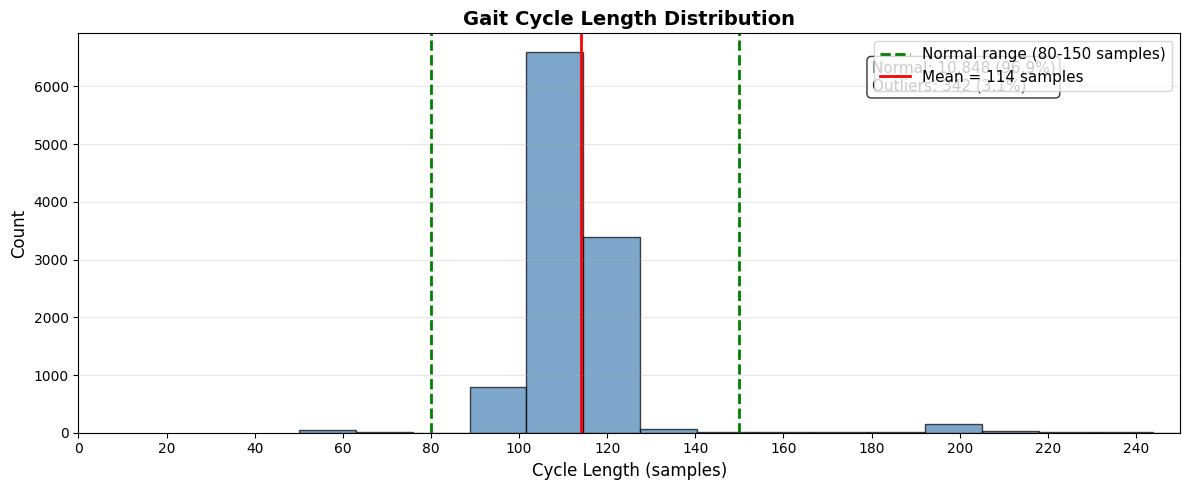

In [34]:
import matplotlib.pyplot as plt
import numpy as np

cycle_lengths = [c['duration_samples'] for c in gait_cycles]

plt.figure(figsize=(12, 5))
plt.hist(cycle_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)

# Mark the filtering boundaries
plt.axvline(x=80, color='green', linestyle='--', linewidth=2, label='Normal range (80-150 samples)')
plt.axvline(x=150, color='green', linestyle='--', linewidth=2)
plt.axvline(x=114, color='red', linestyle='-', linewidth=2, label='Mean = 114 samples')

plt.xlabel('Cycle Length (samples)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Gait Cycle Length Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

# FIX: Set axis limits to zoom in on relevant range
plt.xlim(0, 250)  # Focus on 0-250 samples instead of 0-700
plt.xticks(range(0, 260, 20))

# Add summary text
max_count = max(np.histogram(cycle_lengths, bins=50)[0])
plt.text(180, max_count*0.9, 
         f'Normal: 10,848 (96.9%)\nOutliers: 342 (3.1%)', 
         fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

### Intepretation
- Main finding: 96.9% of gait cycles fall within normal walking range (80-150 samples, between green lines)
#### Key observations:
- Tight clustering around 100-120 samples indicates consistent walking cadence
- Mean of 114 samples (1.14 seconds) confirms normal walking speed
- Only 3.1% outliers (small bars outside green lines) demonstrates robust detection

- Conclusion: High-quality data with minimal detection errors. 

## 7. Time Normalization
- Make all gait cycles the same length so neural networks can process them.

#### Filter out outlier gait cycles

In [35]:
# Step 8.1: Filter out outlier gait cycles

print("="*60)
print("FILTERING OUTLIER CYCLES")
print("="*60)

min_dur, max_dur = 80, 150   # 0.8–1.5 sec at 100 Hz

# Keep only cycles within duration range
filtered_cycles = [c for c in gait_cycles 
                   if min_dur <= c['duration_samples'] <= max_dur]

# Summary
removed = len(gait_cycles) - len(filtered_cycles)

print(f"Original cycles: {len(gait_cycles)}")
print(f"Filtered cycles: {len(filtered_cycles)}")
print(f"Removed: {removed} outliers ({removed/len(gait_cycles)*100:.1f}%)")

# Duration statistics
dur = [c['duration_samples'] for c in filtered_cycles]

print("\nAfter filtering:")
print(f"Duration range: {min(dur)}–{max(dur)} samples")
print(f"Average: {np.mean(dur):.0f} samples")

# Foot counts
left = sum(c['foot'] == 'left' for c in filtered_cycles)
right = sum(c['foot'] == 'right' for c in filtered_cycles)

print(f"Left foot: {left} cycles")
print(f"Right foot: {right} cycles")
print("="*60)

FILTERING OUTLIER CYCLES
Original cycles: 11190
Filtered cycles: 10848
Removed: 342 outliers (3.1%)

After filtering:
Duration range: 80–145 samples
Average: 111 samples
Left foot: 5522 cycles
Right foot: 5326 cycles


### Time normalization

In [36]:
from scipy.signal import resample

# Normalize all cycles to 100 samples
print("="*70)
print("NORMALIZING GAIT CYCLES TO 100 SAMPLES")
print("="*70)

normalized_cycles = []

for cycle in filtered_cycles:
    # Resample each sensor from varying length → 100 samples
    normalized_cycle = cycle.copy()
    
    # Resample IMU sensors
    for sensor in ['sacrum_imu', 'left_shank_imu', 'right_shank_imu']:
        original_data = cycle[sensor]
        resampled_data = {}
        
        for col in original_data.columns:
            resampled_data[col] = resample(original_data[col].values, 100)
        
        normalized_cycle[sensor] = pd.DataFrame(resampled_data)
    
    # Resample GRF
    original_grf = cycle['grf']
    resampled_grf = {}
    
    for col in original_grf.columns:
        resampled_grf[col] = resample(original_grf[col].values, 100)
    
    normalized_cycle['grf'] = pd.DataFrame(resampled_grf)
    normalized_cycle['duration_samples'] = 100  # Update duration
    
    normalized_cycles.append(normalized_cycle)

print(f"Normalized {len(normalized_cycles)} cycles to 100 samples")
print(f"\nVerification (first cycle):")
print(f"  Sacrum IMU: {normalized_cycles[0]['sacrum_imu'].shape}")
print(f"  Left Shank IMU: {normalized_cycles[0]['left_shank_imu'].shape}")
print(f"  Right Shank IMU: {normalized_cycles[0]['right_shank_imu'].shape}")
print(f"  GRF: {normalized_cycles[0]['grf'].shape}")
print("="*70)

NORMALIZING GAIT CYCLES TO 100 SAMPLES
Normalized 10848 cycles to 100 samples

Verification (first cycle):
  Sacrum IMU: (100, 6)
  Left Shank IMU: (100, 6)
  Right Shank IMU: (100, 6)
  GRF: (100, 6)


### Intepretation
Gait cycles were time-normalized to 100 samples using linear interpolation (scipy.signal.resample), following standard practice in gait analysis (Song et al., 2025). This represents discrete percentage points (0-100%) across the gait cycle and ensures fixed-size inputs for neural network training

## 8. Create Input Data Pairs
1. Configuration 1 - Sacrum only:
- Input (X): Sacrum IMU (100, 6)
- Output (y): GRF (100, 6)

2. Configuration 2 - Bilateral shanks:
- Input (X): Left shank + Right shank (100, 12) - concatenated
- Output (y): GRF (100, 6)

3. Configuration 3 - Fusion:
- Input (X): Sacrum + Left shank + Right shank (100, 18) - all concatenated
- Output (y): GRF (100, 6)

In [37]:
import numpy as np

# Step 9: Create Input-Output Pairs for 3 Configurations
print("="*70)
print("CREATING INPUT-OUTPUT PAIRS")
print("="*70)

# Initialize storage
config1_X = []  # Sacrum only
config2_X = []  # Bilateral shanks
config3_X = []  # Fusion (all sensors)
y = []          # GRF (same for all configurations)

for cycle in normalized_cycles:
    # Extract data
    sacrum = cycle['sacrum_imu'].values      # (100, 6)
    left_shank = cycle['left_shank_imu'].values    # (100, 6)
    right_shank = cycle['right_shank_imu'].values  # (100, 6)
    grf = cycle['grf'].values                # (100, 6)
    
    # Configuration 1: Sacrum only
    config1_X.append(sacrum)
    
    # Configuration 2: Bilateral shanks (concatenate left + right)
    shanks = np.concatenate([left_shank, right_shank], axis=1)  # (100, 12)
    config2_X.append(shanks)
    
    # Configuration 3: Fusion (concatenate all)
    fusion = np.concatenate([sacrum, left_shank, right_shank], axis=1)  # (100, 18)
    config3_X.append(fusion)
    
    # Output is the same for all
    y.append(grf)

# Convert to numpy arrays
config1_X = np.array(config1_X)  # (10848, 100, 6)
config2_X = np.array(config2_X)  # (10848, 100, 12)
config3_X = np.array(config3_X)  # (10848, 100, 18)
y = np.array(y)                  # (10848, 100, 6)

print(f"Configuration 1 (Sacrum only):")
print(f"  Input shape: {config1_X.shape}")
print(f"\nConfiguration 2 (Bilateral shanks):")
print(f"  Input shape: {config2_X.shape}")
print(f"\nConfiguration 3 (Fusion):")
print(f"  Input shape: {config3_X.shape}")
print(f"\nOutput (GRF) shape: {y.shape}")
print("="*70)

CREATING INPUT-OUTPUT PAIRS
Configuration 1 (Sacrum only):
  Input shape: (10848, 100, 6)

Configuration 2 (Bilateral shanks):
  Input shape: (10848, 100, 12)

Configuration 3 (Fusion):
  Input shape: (10848, 100, 18)

Output (GRF) shape: (10848, 100, 6)


In [38]:
# Step 9: Create and Save Separate Datasets for Each Configuration

# Configuration 1: Sacrum only
config1_data = {
    'X': config1_X,  # (10848, 100, 6)
    'y': y           # (10848, 100, 6)
}

# Configuration 2: Bilateral shanks
config2_data = {
    'X': config2_X,  # (10848, 100, 12)
    'y': y           # (10848, 100, 6)
}

# Configuration 3: Fusion
config3_data = {
    'X': config3_X,  # (10848, 100, 18)
    'y': y           # (10848, 100, 6)
}

print("="*70)
print("SAVING CONFIGURATION DATASETS")
print("="*70)

# Save each configuration separately
import joblib
import os

output_dir = '/kaggle/working/ml_datasets'
os.makedirs(output_dir, exist_ok=True)

joblib.dump(config1_data, f'{output_dir}/config1_sacrum.joblib', compress=3)
joblib.dump(config2_data, f'{output_dir}/config2_shanks.joblib', compress=3)
joblib.dump(config3_data, f'{output_dir}/config3_fusion.joblib', compress=3)

print("✓ Saved configuration 1 (Sacrum): config1_sacrum.joblib")
print("✓ Saved configuration 2 (Shanks): config2_shanks.joblib")
print("✓ Saved configuration 3 (Fusion): config3_fusion.joblib")
print(f"\nLocation: {output_dir}")
print("="*70)

SAVING CONFIGURATION DATASETS
✓ Saved configuration 1 (Sacrum): config1_sacrum.joblib
✓ Saved configuration 2 (Shanks): config2_shanks.joblib
✓ Saved configuration 3 (Fusion): config3_fusion.joblib

Location: /kaggle/working/ml_datasets


### Interpretation
1. Data was saved to joblib because it's 3D, and joblib is good for training ML models like LSTM and preserves the shape of the data rather than distorting it.